# Sports Betting Arbitrage Project

In general, an arbitrage is the act of buying an asset in one market and selling it in another to make a risk-free profit. This capitalises on price differences for the same asset across markets. An arbitrage in sports betting (or arb for short, or a surebet) is where you bet on a set of mutually exclusive outcomes with multiple different bookmakers where you are guaranteed a profit regardless of what occurs. Instead of capitalising on price differences for one asset across different markets, an arbitrage in sports betting capitalises on differences in odds for the same event across different bookmakers.

To explain this, I’ll use an example. Imagine there is a sports match between two teams, team A and team B. In this sporting event, no draws are possible; one team must win, and one must lose. The first bookmaker predicts team A is more likely to win, so gives them lower odds and team B better odds. Specifically:

* Bookmaker 1 gives team A odds of 1.5
* Bookmaker 1 gives team B odds of 2.25

However, the second bookmaker disagrees and predicts team B to win, and therefore gives them lower odds and team A better odds. Specifically:

* Bookmaker 2 gives team A odds of 2.25
* Bookmaker 1 gives team B odds of 1.5

If you were to just look at one bookmaker, you could never guarantee a profit, but by looking at both bookmakers together you can see that if you bet £1 on team B via bookmaker 1, and £1 on team A via bookmaker 2, you are guaranteed to win £2.25 regardless of the outcome, making a profit on the £2 you bet.

This is an example of an arbitrage in sports betting; you capitalise on the difference in bookmaker odds to guarantee a profit. Sure bets come about as different bookmakers have different models and algorithms to predict sports matches. In general, you wouldn’t look at just two bookmakers; you would look at many more, and then, depending on the best odds for each outcome, an arbitrage might be possible.

### Condition for an arbitrage opportunity

I want to find the condition where an arbitrage opportunity exists. Logically, when betting on multiple outcomes, we want the payoff in any case to be the same, which means that we bet on each event in such a way that we get a common payout $\large P$ regardless. Let’s suppose we have $\large n$ mutually exclusive outcomes which cover all possible events, and odds $\large o_{i}$ where $\large i \in \{1,2,…,n\}$. To be exact, here $\large o_{i}$ represents the return we get for a £1 bet if our bet wins. We call our bets $\large b_{i}$ where $\large i \in \{1,2,…,n\}$. To get a common payout $\large P$ regardless, we need:

$$
\Large o_{i}b_{i} = P \quad \forall i \quad \text{for some common payout } P
$$

Let us name the total cost of the bets as $\large C$, therefore:
$$
\Large C = \sum_{i=1}^{n} b_{i} = \sum_{i=1}^{n} \frac{P}{o_{i}} = P  \left(\sum_{i=1}^{n} \frac{1}{o_{i}}\right)
$$

Clearly, an arbitrage is possible if and only if our common payout $\large P$ is more than the total cost $\large \left( C \right)$ of the bets, so:

$$
\large \text{We make money if } P > C \iff P > P  \left(\sum_{i=1}^{n} \frac{1}{o_{i}}\right) \iff \sum_{i=1}^{n} \frac{1}{o_{i}} < 1
$$

So:

$$
\Large \text{ There is an arbitrage opportunity } \iff \sum_{i=1}^{n} \frac{1}{o_{i}} < 1
$$

Now that we understand what a sports betting arbitrage is and the conditions under which it exists, I want to make a calculator that, given odds values, calculates whether an arbitrage is possible. The function below does that by taking in the best odds for two events and calculates whether an arbitrage is possible using the above condition. This works for two mutually exclusive events that cover all outcomes, for example, betting on the Knicks to win and the Spurs to win in an NBA match where no draws are possible.

In [1]:
#basic arbitrage calc 

def arbitrage_checker_basic(odds1,odds2):
    val = 1/odds1 + 1/odds2
    if val >= 1:
        print("There is no arbitrage possible, don't bet on this match.")
    if val < 1:
        print('There is an arbitrage possible, you should bet on this match.')
        
arbitrage_checker_basic(2.25,2.25)

There is an arbitrage possible, you should bet on this match.


This is an incredibly simple function that takes the odds and calculates, using our above condition, whether an arbitrage is possible, but doesn't really help us much. 

What would be much better is a function that not only checks if an arbitrage is possible but, if one is, gives us the values to bet on each outcome given a stake (total amount to bet) and gives us a return on investment too. This is calculated as follows:
$$
\large \text{return on investment } = \frac{P-C}{C} 
$$

In the function, we use this and multiply by 100 to get a percentage return on investment.

In [2]:
#arbitrage calculator with stake and suggested bets

def arbitrage_checker(odds1,odds2,total_stake):
    val = 1/odds1 + 1/odds2 
    if val >= 1:
        print("Unfortunately there is no arbitrage possible, don't bet on this match.")
    else:
        common_payout = total_stake * 1/val
        stake_on_1 = common_payout/odds1
        stake_on_2 = common_payout/odds2
        pos_return = ((common_payout-total_stake)/total_stake) * 100
        print('An arbitrage is possible.')
        print(f'You should bet {stake_on_1} on the 1st outcome, and {stake_on_2} on the second, to get a {pos_return}% return on investment.')

arbitrage_checker(2.1,2.25,10) 

An arbitrage is possible.
You should bet 5.172413793103448 on the 1st outcome, and 4.827586206896552 on the second, to get a 8.62068965517242% return on investment.


This function gives us values to bet on given the odds and stake, but there is an important catch.

In practice we can only bet with decimal values; money isn't continuous. So if our function tells us to bet on something with £$\frac{2}{3}$, we must round. However, this will reduce our profits and, in some cases, could wipe the arbitrage opportunity out altogether, so we need to carefully round and check if we still have our profit margin. 

The next function carefully looks at the possible pairs of bets near our perfect betting pair and then checks if we still can make a risk-free profit.

In [3]:
#arbitrage calculator, rounding

import math

def arbitrage_checker_round(odds1,odds2,stake):
    val = 1/odds1 + 1/odds2 
    if val >= 1:
        print("Unfortunately there is no arbitrage possible, don't bet on this match.")
    else:
        common_payout = stake * 1/val
        stake_on_1 = common_payout/odds1
        stake_on_2 = common_payout/odds2
        stake_1_rounded = round(stake_on_1,2) - 0.02
        stake_2_rounded = round(stake_on_2,2) - 0.02
        current_max_payout = 0
        bet_values = [0,0]
        for i in range(5):   
            test_stake_on_1 = stake_1_rounded + i*(0.01)
            test_stake_on_2 = stake_2_rounded + 0.04 - i*(0.01)
            min_test_payout = min(odds1 * test_stake_on_1,odds2 * test_stake_on_2)
            if min_test_payout > current_max_payout:
                bet_values = [test_stake_on_1,test_stake_on_2]
                current_max_payout = min_test_payout
        current_max_payout_floor = math.floor(100*current_max_payout)/100
        pos_return = round(100*((current_max_payout_floor - stake)/stake),2)
        if current_max_payout_floor > stake:
            print('An arbitrage is possible.')
            print(f'You should bet £{round(bet_values[0],2)} on the 1st outcome, and £{round(bet_values[1],2)} on the second.')
            print(f'Your maximum guaranteed payout is £{round(current_max_payout_floor,2)} for a total bet of £{round(stake,2)}.') 
            print(f'Which gives you a {round(pos_return,2)}% return on investment.')
        else: 
            print('An arbitrage is possible but not possible with the stake provided.')
        
arbitrage_checker_round(1.2,7,10)

An arbitrage is possible.
You should bet £8.53 on the 1st outcome, and £1.47 on the second.
Your maximum guaranteed payout is £10.23 for a total bet of £10.
Which gives you a 2.3% return on investment.


This calculator is much more complex; it now takes in the odds and a stake (amount bet) and gives you the exact values to put on each outcome. The function takes in a stake in pound increments and gives you betting values in pennies. A simple (but not the most effective) way to do this would just be to get the perfect stake values and round them to the nearest penny. But it's possible that this doesn't get the best payoff; what my function does is:
$$
\Large \underset{bet pairings}{max} \left( \text{ }\underset{outcomes}{min} \left( Payout \right) \right)
$$

Where $\large Payout$ is the payout of the specific outcome. So essentially, for each bet pairing, it looks at the payoff of each outcome and gets the bet pairing that guarantees the highest minimum payout. The bet pairings it tests are the ones closest to the calculated perfect stakes, as we often can't use these exactly.

In other words, it finds the maximum of the minimum payout for the bet pairings. It's the same idea as treating a discrete function as continuous to find the derivative, then the maximum, and then checking the values around the continuous maximum to find the discrete maximum. We can't bet in continuous values, but we have found the perfect stakes if we could, and we are now translating that to increments we can bet in. The function then returns the bets you should make and gives you the return on investment.

An arbitrage calculator I found online simply rounds the theoretical stakes and doesn't do any checks. For the above odds and stake (odds of 1.2, 7 and a stake of £10), it suggests betting £8.54 and £1.46 respectively. We can see why this is non-optimal below:

- If the 1st event comes true, my calculated stakes give a payout of £10.236, which is given as £10.23
- If the 2nd event comes true, my calculated stakes give a payout of £10.29

Now for the online calculator:

- If the 1st event comes true, we get a payout of £10.248, given as £10.24
- If the 2nd event comes true, we get a payout of £10.22

So I am guaranteed a payoff of £10.23, yet they are only guaranteed a payoff of £10.22. The online calculator also says that payoffs are £10.24 regardless, which is the payout with the best theoretical stakes. It simply rounds the best theoretical stakes, but this isn't optimal. As you can see in this example, carelessly rounding will narrow the profit margin and, in extreme cases, can get rid of it altogether. I also took the floor (in pennies) of the payout and profit, as that's how the payout often works in sports betting and it's the smallest payout that could be given. 

Checking the payouts carefully like this is a very important detail which guarantees the highest minimum payout. Also, as some bookmakers only allow larger increments such as £0.10 or £1, the above function can be fairly easily be adjusted to that, and importantly, the larger the minimum increment, the further away we are likely to be from the optimal value and the smaller returns we get. 

Now we have seen this and coded a function which finds the best bet in pennies. I think it's good to look at some real-world examples, but first we must note how odds are displayed in the UK. In the UK, sports odds are generally shown as fractional odds, e.g. 2/1. This means that for a £1 bet, if our bet wins, we get £2 plus our original £1 bet back, £3 total. In general:

$
\Large \text{Odds of a/b means that when betting £b we get £(a+b) if our bet wins}
$

So, when we bet £b, we profit £a if our bet pays out. Since this is the most common type of odds in the UK and the one we'll use later, I have adjusted the following arbitrage checker for fractional odds. To convert from fractional odds to decimal odds, we just add 1, since we need to include the original stake in the payout. 

In [4]:
#arbitrage checker, fractional odds.

import math

def arbitrage_checker_fractional(frac_odds1,frac_odds2,stake):
    odds1 = frac_odds1 + 1 #adjusting to decimal odds
    odds2 = frac_odds2 + 1
    val = 1/odds1 + 1/odds2 
    if val >= 1:
        print("Unfortunately there is no arbitrage possible, don't bet on this match.")
    else:
        common_payout = stake * 1/val
        stake_on_1 = common_payout/odds1
        stake_on_2 = common_payout/odds2
        stake_1_rounded = round(stake_on_1,2) - 0.02
        stake_2_rounded = round(stake_on_2,2) - 0.02
        current_max_payout = 0
        bet_values = [0,0]
        for i in range(5):   
            test_stake_on_1 = stake_1_rounded + i*(0.01)
            test_stake_on_2 = stake_2_rounded + 0.04 - i*(0.01)
            min_test_payout = min(odds1 * test_stake_on_1,odds2 * test_stake_on_2)
            if min_test_payout > current_max_payout:
                bet_values = [test_stake_on_1,test_stake_on_2]
                current_max_payout = min_test_payout
        current_max_payout_floor = math.floor(100*current_max_payout)/100
        pos_return = round(100*((current_max_payout_floor - stake)/stake),2)
        if current_max_payout_floor > stake:
            print('An arbitrage is possible.')
            print(f'You should bet £{round(bet_values[0],2)} on the 1st outcome, and £{round(bet_values[1],2)} on the second.')
            print(f'Your maximum guaranteed payout is £{round(current_max_payout_floor,2)} for a bet of £{round(stake,2)}.') 
            print(f'Which gives you a {round(pos_return,2)}% return on investment.')
        else: 
            print('An arbitrage is possible but not possible with the stake provided.')
        
arbitrage_checker_fractional(1/1,21/20,10)

An arbitrage is possible.
You should bet £5.06 on the 1st outcome, and £4.94 on the second.
Your maximum guaranteed payout is £10.11 for a bet of £10.
Which gives you a 1.1% return on investment.


Now that we have built functions that take a given set of odds and calculate the values to bet on each outcome when an arbitrage opportunity is available, I decided to examine some real-world examples. After investigating several sports and competitions, I found that ATP Challenger and ITF Tour men’s professional tennis tournaments provide a useful market to study, with many matches and observable arbitrage opportunities.

### Dataset

I want to analyse a large dataset of matches to investigate how different variables influence arbitrage opportunities. I manually collected historical tennis betting odds for this analysis. I have not included the underlying dataset in this repository due to restrictions on publicly redistributing the source data.

I focused on the following tournament levels:

* ATP Challenger 125
* ATP Challenger 75
* ATP Challenger 50
* ITF M25
* ITF M15

These are listed in decreasing order of tournament level, with ATP Challenger 125 being the highest level. All five categories are professional men’s tennis tournaments. 

For each tournament level, I selected 20 tournaments between February and July 2026. The tournaments were selected to provide a representative spread across different surfaces and locations. The three main tennis surfaces are clay, hard, and grass, with clay and hard tournaments being much more common. Tournaments are held across the world, although a larger proportion take place in Europe.

The odds used in the analysis are the closing odds for each match, representing the best available odds for each player immediately before the match began.

In [5]:
import json

with open("tennis_odds.json", "r") as f:
    tennis_odds = json.load(f)

print(len(tennis_odds))

5


A length of 5 indicates that our data contains five tournament levels, ordered from highest to lowest as above.

Now we have a large database of odds for 100 tennis tournaments. The way we format the data is very important and will make it much easier to compare arbitrage opportunities later on.  This is very useful and will allow us to analyse many variables, but first I want to have a function that simply takes a pair of odds (which will later be the best closing odds for each player) and outputs the net return you would get from optimally betting on them. I made this function so that I can call it at any point later to make the code simpler.

In [6]:
#short arbitrage function to call later.

import math 

def arb_return(odds_pair):
    odds1 = odds_pair[0]+ 1
    odds2 = odds_pair[1] + 1
    val = 1/odds1 + 1/odds2 
    return_on_investment = 100 * 1/val
    stake_on_1 = return_on_investment/odds1
    stake_on_2 = return_on_investment/odds2
    stake_1_rounded = round(stake_on_1,2) - 0.02
    stake_2_rounded = round(stake_on_2,2) - 0.02
    current_max_payout = 0
    bet_values = [0,0]
    for i in range(5):   
        test_stake_on_1 = stake_1_rounded + i*(0.01)
        test_stake_on_2 = stake_2_rounded + 0.04 - i*(0.01)
        min_test_payout = min(odds1 * test_stake_on_1,odds2 * test_stake_on_2)
        if min_test_payout > current_max_payout:
            bet_values = [test_stake_on_1,test_stake_on_2]
            current_max_payout = min_test_payout
    current_max_payout_floor = math.floor(100*current_max_payout)/100
    net_return = round(current_max_payout_floor - 100,2) #cancelled out x100 and /100 as stake is £100.
    return net_return

print(arb_return([6/5,1/1]))

4.76


This function simply takes a pair of odds and outputs the net return we get using a £100 stake. A £100 stake is a nice round number and sufficiently large to capitalise on almost all arbitrage opportunities. From now on, I call this function to get the net returns to make the code simpler and more compact.

It's important that it just gives us the net return, as it allows us more flexibility later; we can decide whether to include the specific net return or just count the number of arbs. Now we have this function; we can use it to see an overview of the results for the 100 tournaments in our dataset. I have done so below.

In [7]:
#overview of results for all data combined.

def total_arbitrage_list_overview(odds_list):
    no_odds_count = 0
    walkover_count = 0
    arb_count = 0
    match_count = 0
    for l in range(5):
        for i in range(len(odds_list[l])):
            for j in range(len(odds_list[l][i][1])):
                if len(odds_list[l][i][1][j]) == 1:
                    if odds_list[l][i][1][j][0] == 0:
                        no_odds_count += 1
                    elif odds_list[l][i][1][j][0] == 1:
                        walkover_count += 1
                    continue
                match_count += 1
                net_return = arb_return(odds_list[l][i][1][j])
                if net_return > 0:
                       arb_count += 1
    print(f'In total we have looked at {match_count} matches.')
    print(f'Of these matches {arb_count} had an arbitrage opportunity.')
    print(f'Also there were: {no_odds_count} matches with no odds, and {walkover_count} walkover matches') 
    
total_arbitrage_list_overview(tennis_odds)

In total we have looked at 3045 matches.
Of these matches 216 had an arbitrage opportunity.
Also there were: 46 matches with no odds, and 9 walkover matches


So we have 3,045 matches, 216 of which had an arbitrage opportunity. Walkover matches are where one player can't start the match and so all bets are voided. The total number of matches doesn't include matches with no odds or walkover matches, as clearly no arbitrage is possible, and I want to look at the arb % (% of matches with an arbitrage) later and don't want this to affect the results. I counted the number of matches with no odds and walkover matches separately. The function is nice and compact, as I could just call the above arb return function to get the net return easily.

We have lots of information in this dataset, and this is clearly a very basic overview. A good way to visualise the distribution of returns is to see a histogram of the net returns, which I show below.

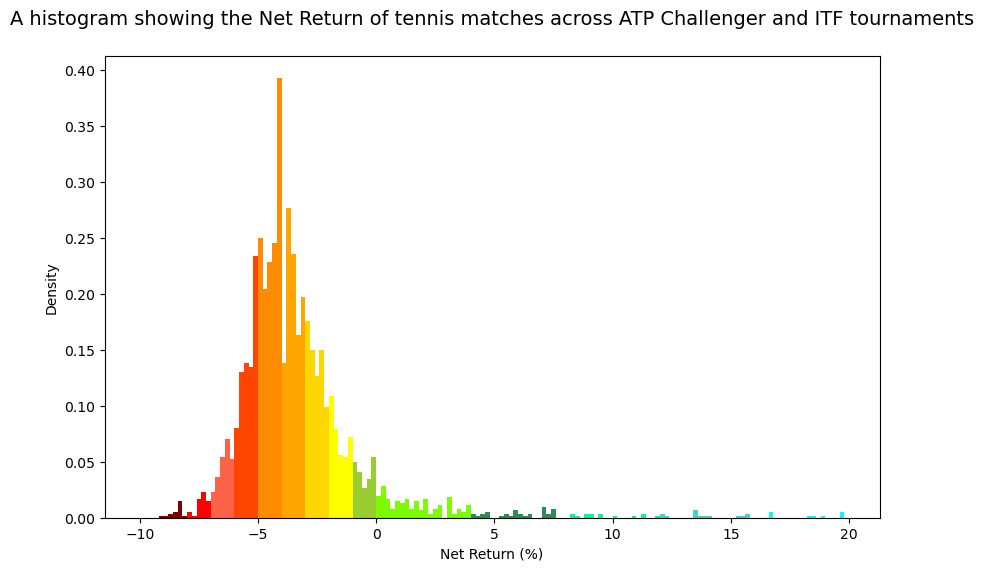

In [8]:
#histogram of net returns for all data combined.

import matplotlib.pyplot as plt
import numpy as np

def total_arbitrage_list_net_returns(odds_list):
    net_return_list = []
    for l in range(5):
        for i in range(len(odds_list[l])):
            for j in range(len(odds_list[l][i][1])):
                if len(odds_list[l][i][1][j]) == 1:
                    continue
                net_return_list.append(arb_return(odds_list[l][i][1][j]))
    return net_return_list

hist_colours_1 = ['maroon','maroon','red','tomato','orangered','darkorange','orange','gold','yellow','yellowgreen'] 
hist_colours_2  = ['lawngreen','seagreen','mediumspringgreen','mediumturquoise','cyan']
hist_bins_1 = np.arange(-10,20,.2)
plt.figure(figsize=(10,6))
_,_,obj = plt.hist(total_arbitrage_list_net_returns(tennis_odds),bins=hist_bins_1,density = True)
        
for i in range(149):
    if i <= 49:
        obj[i].set_fc(hist_colours_1[i//5])
    else:
        obj[i].set_fc(hist_colours_2[((i-50)//20)])

plt.title('A histogram showing the Net Return of tennis matches across ATP Challenger and ITF tournaments',fontsize='14',y=1.05)
plt.xlabel('Net Return (%)')
plt.ylabel('Density')
plt.show()

This gives us a good idea of the distribution of net return across all the matches. Most matches have a slight negative return, which we would expect, as bookmakers have the edge, and this is slightly reduced when looking at the best odds from multiple bookmakers. We can see that there are some arbitrage opportunities, and a few even have returns up to 20%. I again used the arb return function to make the code simpler, which I shall do for the rest of the functions. 

To see how our 3,045 matches are split up by Tournament Level, Surface Type, and Continent, I have made graphs below which show this. This is important to see, as categories with fewer matches are noisier, which is something which we will need to consider later. 

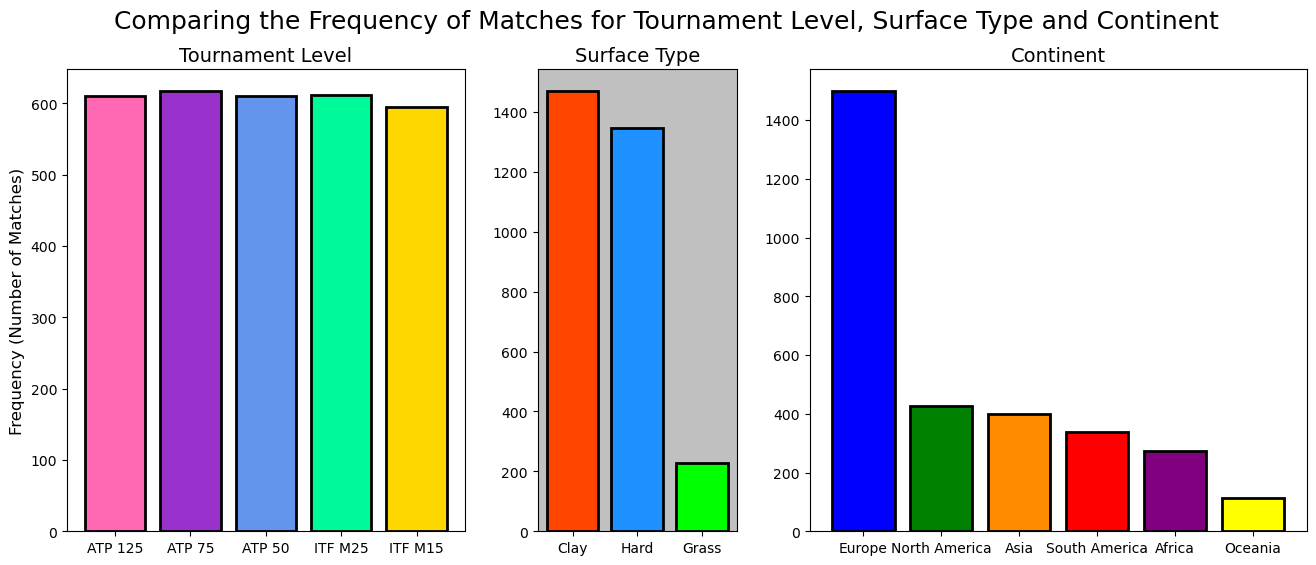

In [9]:
#comparing frequencies of matches for tournament level, surface type and continent.

from collections import Counter
import matplotlib.pyplot as plt

tennis_odds_2 = ['ATP 125',tennis_odds[0],'ATP 75',tennis_odds[1],'ATP 50',tennis_odds[2],'ITF M25',tennis_odds[3],'ITF M15',tennis_odds[4]]

def frequency_data_tournaments(odds_list): #rename all the functions.
    tournament_list = []
    surface_list = []
    continent_list = []
    for l in range(5): #tournament levels
        for i in range(len(odds_list[2*l+1])): #tournaments
            for j in range(len(odds_list[2*l+1][i][1])): #matches
                if len(odds_list[2*l+1][i][1][j]) == 1:
                        continue
                tournament_list.append(odds_list[2*l])
                surface_list.append(odds_list[2*l+1][i][0][1])
                continent_list.append(odds_list[2*l+1][i][0][2])
    return [tournament_list,surface_list,continent_list] 

tournament_count = Counter(frequency_data_tournaments(tennis_odds_2)[0])
surface_count = Counter(frequency_data_tournaments(tennis_odds_2)[1])
continent_count = Counter(frequency_data_tournaments(tennis_odds_2)[2])
tournament_colours = ['hotpink','darkorchid','cornflowerblue','mediumspringgreen','gold'] 
surface_colours = ['orangered','dodgerblue','lime']
continent_colours = ['blue','green','darkorange','red','purple','yellow']
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize = (16,6),gridspec_kw={'width_ratios': [4,2,5]})
fig.suptitle('Comparing the Frequency of Matches for Tournament Level, Surface Type and Continent',fontsize = '18')
ax1.bar(tournament_count.keys(),tournament_count.values(),color = tournament_colours,edgecolor = 'black',linewidth = 2)
ax1.set_title('Tournament Level',fontsize = '14')
ax1.set_ylabel('Frequency (Number of Matches)',fontsize = '12')
ax2.bar(surface_count.keys(),surface_count.values(), color = surface_colours,edgecolor = 'black',linewidth = 2)
ax2.set_facecolor('silver')
ax2.set_title('Surface Type',fontsize = '14')
ax3.bar(continent_count.keys(),continent_count.values(), color = continent_colours,edgecolor = 'black',linewidth = 2)
ax3.set_title('Continent',fontsize = '14')
plt.show()

These graphs represent how our 3,045 matches are split across Tournament Level, Surface Type, and Continent. We chose 20 tournaments of each level, so it's not surprising that they are very evenly matched in terms of number of matches. We have much more clay and hard matches than grass, which makes sense as grass is much less common as a surface type. Europe is by far the most common continent for tournaments, as many countries in Europe regularly host tournaments. It's split up quite evenly amongst the rest, with not many in Oceania. This is important to see as our data for Oceania and Grass will be much noisier, and that's something to account for when comparing arbitrage opportunities.

An important thing to consider is how the variables affect each other; the main variables I'm focusing on are the Tournament Level and Surface Type, but these could easily impact one another. For example, when comparing arbitrage opportunities across tournament levels, differences in the distribution of surface types between tournament levels could skew the results, making it difficult to determine whether differences in arbitrage opportunities are due to tournament level or surface type. The same can be true for the surfaces, and one surface type might have much more from a specific tournament level, which impacts our findings. 

To see how the surface types are distributed among tournament levels, I wanted to break down the tournament levels by surface type, which I have done below. 

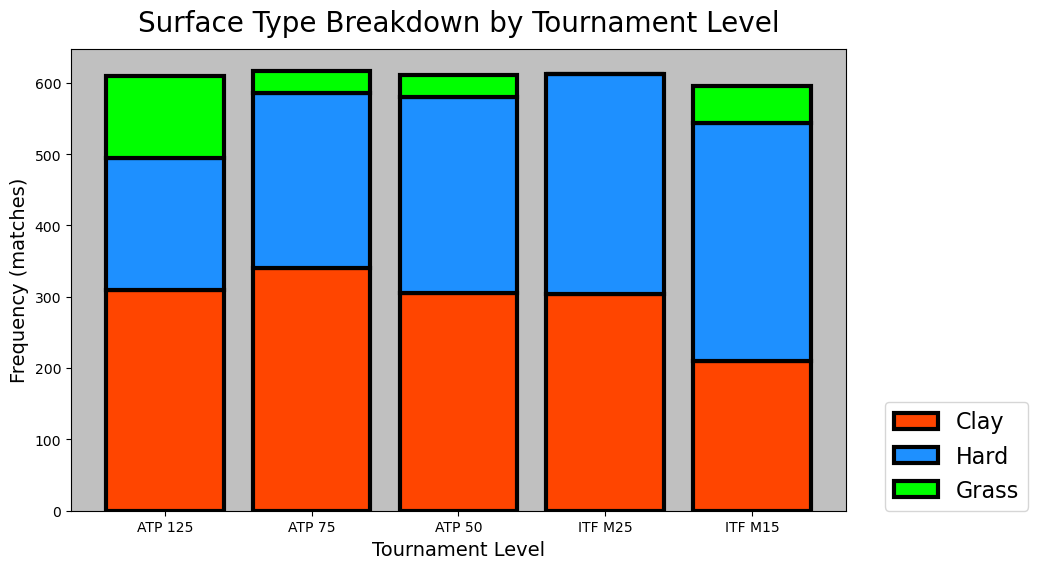

In [10]:
#breakdown of tournament levels into surface types.

from collections import Counter
import matplotlib.pyplot as plt

def frequency_tournament_level_surfaces(odds_list): 
    tournament_surface_list = []
    for l in range(5): #tournament levels
        for i in range(len(odds_list[2*l+1])): #tournaments
            for j in range(len(odds_list[2*l+1][i][1])): #matches
                if len(odds_list[2*l+1][i][1][j]) == 1:
                        continue
                tournament_surface_list.append(odds_list[2*l] + ' ' + odds_list[2*l+1][i][0][1])
    return tournament_surface_list

tournament_surface_count = Counter(frequency_tournament_level_surfaces(tennis_odds_2))
tournaments = ['ATP 125','ATP 75','ATP 50','ITF M25','ITF M15']
clay_tournament_frequencies = [0] * 5
hard_tournament_frequencies = [0] * 5
grass_tournament_frequencies = [0] * 5
clay_and_grass_freq = [0] * 5
for i in range(5):
    key_clay = tennis_odds_2[2*i] + ' ' + 'Clay'
    key_hard = tennis_odds_2[2*i] + ' ' + 'Hard'
    key_grass = tennis_odds_2[2*i] + ' ' + 'Grass'
    clay_tournament_frequencies[i] = tournament_surface_count[key_clay]
    hard_tournament_frequencies[i] = tournament_surface_count[key_hard]
    grass_tournament_frequencies[i] = tournament_surface_count[key_grass]
    clay_and_grass_freq[i] = tournament_surface_count[key_clay] + tournament_surface_count[key_hard]

plt.figure(figsize=(10,6))
surface_colours = ['orangered','dodgerblue','lime'] 
plt.bar(tournaments, clay_tournament_frequencies, color=surface_colours[0],edgecolor = 'black', linewidth = 3)
plt.bar(tournaments, hard_tournament_frequencies, bottom=clay_tournament_frequencies, color=surface_colours[1],edgecolor = 'black', linewidth = 3)
plt.bar(tournaments, grass_tournament_frequencies, bottom=clay_and_grass_freq, color=surface_colours[2],edgecolor = 'black', linewidth = 3)
ax = plt.gca()
ax.set_facecolor('silver')
plt.title("Surface Type Breakdown by Tournament Level",fontsize = '20',y=1.02)
plt.xlabel("Tournament Level",fontsize = '14')
plt.ylabel("Frequency (matches)", fontsize = '14')
plt.legend(["Clay", "Hard", "Grass"],loc = [1.05,0],prop={'size': 16})
plt.show()

In this graph, we can see that Clay and Hard cover the vast majority of matches. Grass is much less common overall but more common in ATP 125, which could definitely impact our results when comparing arbitrage opportunities across surface types. We need to account for this information when comparing arbitrage opportunities across both tournament levels and surface types. There are also no grass matches for ITF M25.  

In general, I chose a representative set of tournaments for each tournament level, except with ITF M15 I chose 2 grass tournaments despite there only being 2, as I wanted more data for grass tournaments to compare how surface affects arbitrage opportunities.  

I now look at the distribution of net returns for ATP vs. ITF tournaments. 

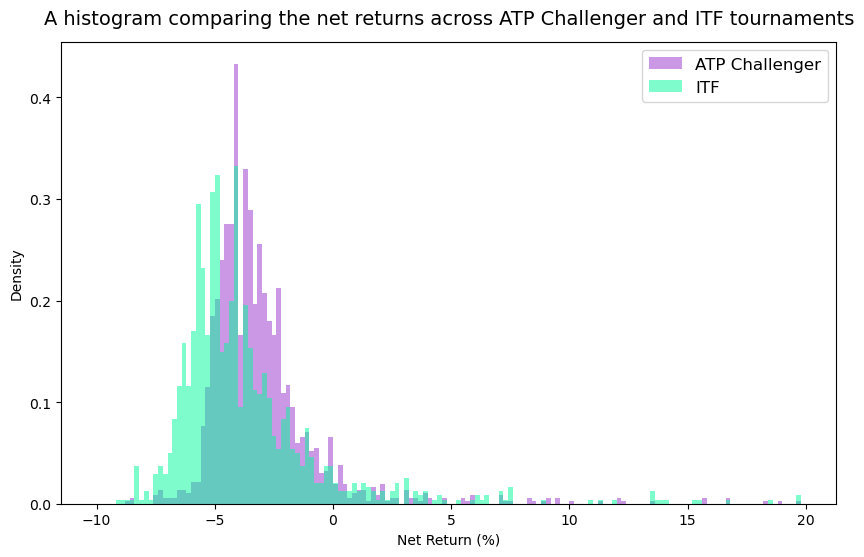

In [11]:
#comparing net returns for atp and itf.

import matplotlib.pyplot as plt
import numpy as np

def arbitrage_list_net_returns_atp_itf(odds_list):
    atp_return_list = []
    itf_return_list = []
    for l in range(5):
        for i in range(len(odds_list[l])):
            for j in range(len(odds_list[l][i][1])):
                if len(odds_list[l][i][1][j]) == 1:
                    continue
                net_return = arb_return(odds_list[l][i][1][j])
                if l < 3:
                    atp_return_list.append(net_return)
                else:
                    itf_return_list.append(net_return)
                
    return [atp_return_list,itf_return_list]

hist_bins_2 = np.arange(-10,20,.2)
plt.figure(figsize=(10,6))
plt.hist(arbitrage_list_net_returns_atp_itf(tennis_odds)[0],density=True,bins=hist_bins_2,alpha=0.5,color = 'darkorchid')
plt.hist(arbitrage_list_net_returns_atp_itf(tennis_odds)[1],density=True,bins=hist_bins_2,alpha=0.5, color = 'mediumspringgreen')
plt.title('A histogram comparing the net returns across ATP Challenger and ITF tournaments',fontsize='14',y=1.02)
plt.xlabel('Net Return (%)')
plt.ylabel('Density')
plt.legend(["ATP Challenger", "ITF"],loc = 'upper right',prop={'size': 12})
plt.show()

This gives us a good comparison of the distribution of net returns between ATP Challenger and ITF tournaments. The ATP is much more compact, with fewer outliers, whereas the ITF is more varied, with more values with a positive return and many more less than -5. This is to be expected as the ITF tour is a lower level and so bets are likely to be less efficient. As the ITF tournaments are smaller, bookmakers will also want to take a larger cut as there is less volume of bets with a similar operational cost to larger competitions.

This is similar to how market makers may widen their bid-ask spreads during periods of increased volatility or uncertainty, as these conditions can increase the risk and cost of adverse selection. Similarly, bookmakers may price more conservatively in smaller tournaments due to greater uncertainty and less available information.

## Comparing Arbitrage Opportunities Across Tournament Levels

Now I want to do a comparison of the arbitrage opportunities among tournament levels. I would expect there to be better arbitrage opportunities in lower tournament levels due to higher bookmaker disagreement. There are many possible ways of quantifying arbitrage opportunities. A basic way of comparing arbitrage opportunities is just looking at the arb %, which is the percentage of matches with an arbitrage opportunity. To be clear

$$
\large \text{arb %} = \frac{\text{Number of arb matches}}{\text{Total number of matches}}
$$

Where the total number of matches is only matches that could have had an arbitrage opportunity (discounting matches with no odds and walkover matches). I will start with this, just comparing the arb % across tournament levels.

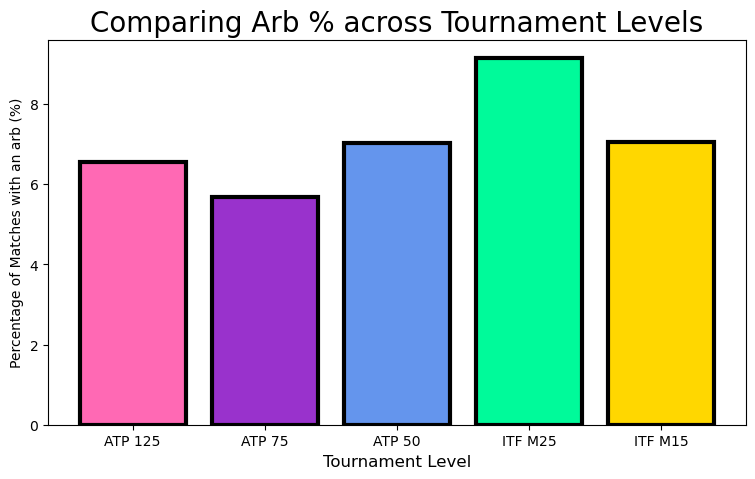

In [12]:
#comparing arb % over tournament levels

import matplotlib.pyplot as plt
import numpy as np

def arbitrage_percentage_tournament_level(odds_list):
    match_counter = [0] * 5
    arb_matches = [0] * 5
    arb_percentages = [0] * 5
    for l in range(5):
        for i in range(len(odds_list[l])):
            for j in range(len(odds_list[l][i][1])):
                if len(odds_list[l][i][1][j]) == 1:
                    continue
                match_counter[l] += 1
                if arb_return(odds_list[l][i][1][j]) > 0: 
                    arb_matches[l] += 1
    for m in range(5):
        arb_percentages[m] = 100*(arb_matches[m]/match_counter[m])
    return arb_percentages
     

tournament_levels = ['ATP 125', 'ATP 75', 'ATP 50', 'ITF M25', 'ITF M15']
tournament_colours = ['hotpink','darkorchid','cornflowerblue','mediumspringgreen','gold'] 
plt.figure(figsize=(9,5))
plt.bar(tournament_levels,arbitrage_percentage_tournament_level(tennis_odds), color = tournament_colours, edgecolor = 'black', linewidth = 3)
plt.xlabel('Tournament Level',fontsize = '12')
plt.ylabel('Percentage of Matches with an arb (%)')
plt.title('Comparing Arb % across Tournament Levels',fontsize = '20')
plt.show()

This is a simple comparison to see how the arb % compares across tournament levels. The arb % increases a little as the tournament level decreases, as there is less reliable information and matches are more unpredictable. 

This is a naive comparison, and that is because we know that surface type could be impacting our results. By just comparing amongst tournament levels, we don't account for this and therefore can't make any meaningful conclusions. 

To account for surface type affecting the arb %, we can compare the arb % across tournament levels for each surface type to get a real idea of how tournament level impacts the arbitrage opportunities. The graphs of that are below.  

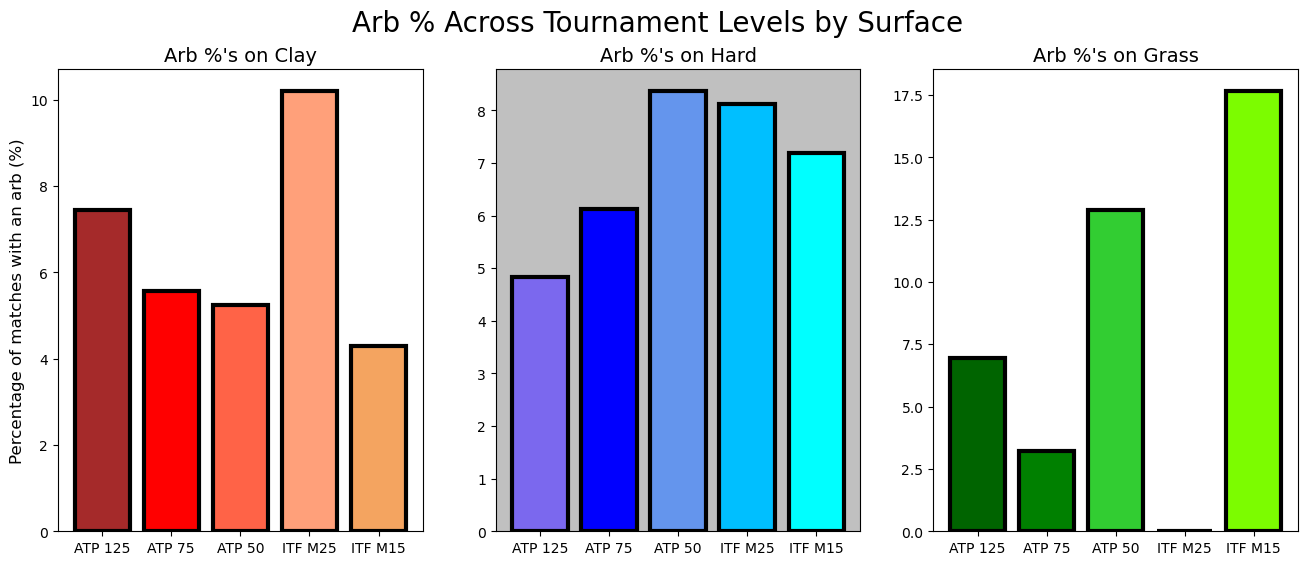

In [13]:
#comparing arb % among tournament levels for each surface.

import matplotlib.pyplot as plt
import numpy as np

def arbitrage_percentage_tournament_level_surfaces(odds_list):
    match_counter = [[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0]] 
    arb_matches = [[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0]] 
    arb_percentages = [[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0]] 
    for l in range(5):
        for i in range(len(odds_list[l])):
            for j in range(len(odds_list[l][i][1])):
                if len(odds_list[l][i][1][j]) == 1:
                    continue
                net_return = arb_return(odds_list[l][i][1][j])
                if odds_list[l][i][0][1] == 'Clay':
                    match_counter[0][l] += 1
                    if net_return > 0 :
                        arb_matches[0][l] += 1
                elif odds_list[l][i][0][1] == 'Hard':
                    match_counter[1][l] += 1
                    if net_return > 0 :
                        arb_matches[1][l] += 1
                elif odds_list[l][i][0][1] == 'Grass':
                    match_counter[2][l] += 1
                    if net_return > 0 :
                        arb_matches[2][l] += 1
    for m in range(3):
        for n in range(5):
            if match_counter[m][n] == 0:
                arb_percentages[m][n] = 0
            else:
                arb_percentages[m][n] = 100*(arb_matches[m][n]/match_counter[m][n])
    return arb_percentages

tournament_levels = ['ATP 125', 'ATP 75', 'ATP 50', 'ITF M25', 'ITF M15']
clay_colours = ['brown','red','tomato','lightsalmon','sandybrown'] 
hard_colours = ['mediumslateblue','blue','cornflowerblue','deepskyblue','cyan'] 
grass_colours = ['darkgreen','green','limegreen','springgreen','lawngreen']
colours2 = ['dimgrey','grey','darkgrey','lightgrey','white']
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize = (16,6),gridspec_kw={'width_ratios': [1,1,1]})
fig.suptitle('Arb % Across Tournament Levels by Surface',fontsize = '20')
ax1.bar(tournament_levels,arbitrage_percentage_tournament_level_surfaces(tennis_odds)[0],color = clay_colours,edgecolor = 'black',linewidth = 3)
ax1.set_title("Arb %'s on Clay",fontsize = '14')
ax1.set_ylabel('Percentage of matches with an arb (%)',fontsize = '12')
ax2.bar(tournament_levels,arbitrage_percentage_tournament_level_surfaces(tennis_odds)[1], color = hard_colours,edgecolor = 'black',linewidth = 3)
ax2.set_fc('silver')
ax2.set_title("Arb %'s on Hard",fontsize = '14')
ax3.bar(tournament_levels,arbitrage_percentage_tournament_level_surfaces(tennis_odds)[2], color = grass_colours,edgecolor = 'black',linewidth = 3)
ax3.set_title("Arb %'s on Grass",fontsize = '14')
plt.show()

Here, we can see that, in general, arb % increases as tournament level decreases across each surface type. There isn't a perfect correlation, and there are some outliers, but it shows a clear increase in the arb % for lower tournament levels. An important note is that by doing this breakdown into surface types, we make the comparison better, but we also make the data noisier, which could be a reason for some of the outliers. This is especially true for the grass tournaments, as we have so few of these. There were no ITF M25 tournaments on grass in our dataset, which is why the bar is shown as 0.   

Arb % is a nice, simple way to look compare arbitrage opportunities, but it misses out on a lot of information. For example, this only considers whether there is an arbitrage or not and doesn't factor in how large the positive return will be. An arbitrage opportunity of 1% and 10% are treated as identical in this comparison, which doesn't feel fair. 

A way of accounting for the size of each opportunity would be to compare the total positive returns of arbitrages per match among tournament levels for each surface type. To be exact:

$$ 
\large \text{Arb return per match} = \frac{\text{Total positive arb return}}{\text{Total number of matches}}
$$

The total positive arb return is just the sum of the returns over all matches with an arbitrage opportunity, and the total number of matches is the same as before. The graphs for this are below. 

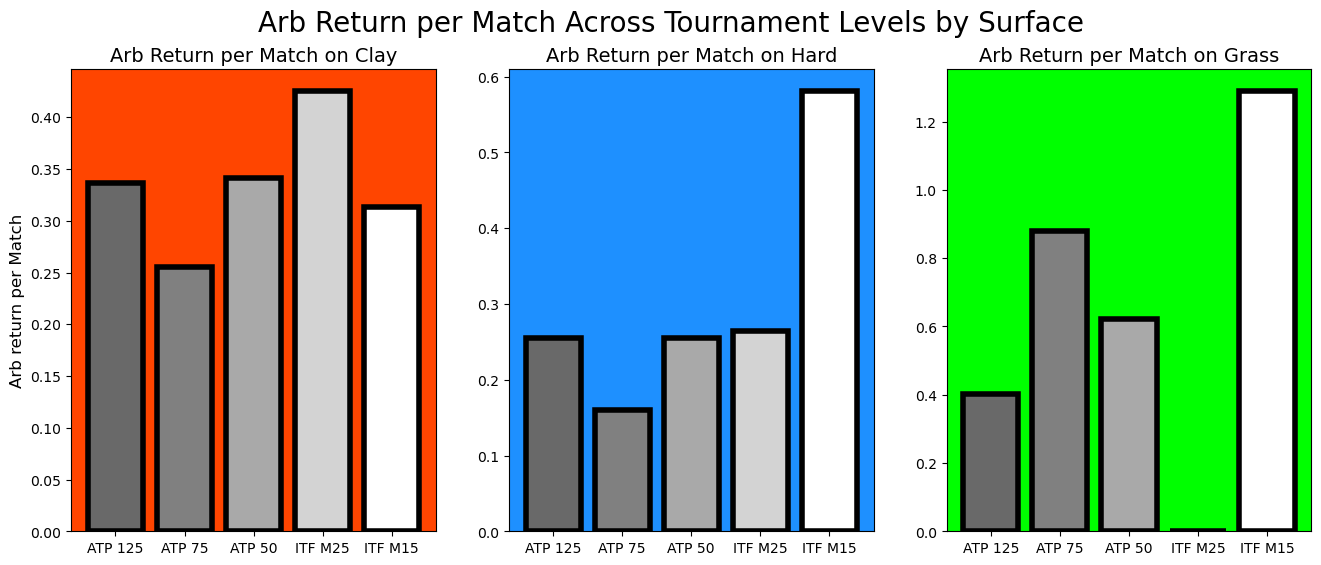

In [14]:
#comparing the average positive arb return per match among tournament levels for each surface type

import matplotlib.pyplot as plt
import numpy as np

def arbitrage_pos_return_tournament_level_surfaces(odds_list):
    match_counter = [[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0]] 
    total_positive_return = [[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0]] 
    arb_return_per_match = [[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0]] 
    for l in range(5):
        for i in range(len(odds_list[l])):
            for j in range(len(odds_list[l][i][1])):
                if len(odds_list[l][i][1][j]) == 1:
                    continue
                net_return = arb_return(odds_list[l][i][1][j])
                if odds_list[l][i][0][1] == 'Clay':
                    match_counter[0][l] += 1
                    if net_return > 0 :
                        total_positive_return[0][l] += arb_return(odds_list[l][i][1][j])
                elif odds_list[l][i][0][1] == 'Hard':
                    match_counter[1][l] += 1
                    if net_return > 0 :
                        total_positive_return[1][l] += arb_return(odds_list[l][i][1][j])
                elif odds_list[l][i][0][1] == 'Grass':
                    match_counter[2][l] += 1
                    if net_return > 0 :
                        total_positive_return[2][l] += arb_return(odds_list[l][i][1][j])
    for m in range(3):
        for n in range(5):
            if match_counter[m][n] == 0:
                arb_return_per_match[m][n] = 0
            else:
                arb_return_per_match[m][n] = total_positive_return[m][n]/match_counter[m][n]
    return arb_return_per_match

surface_colours = ['orangered','dodgerblue','lime']
tournament_levels = ['ATP 125', 'ATP 75', 'ATP 50', 'ITF M25', 'ITF M15']
greyscale_5_colours = ['dimgrey','grey','darkgrey','lightgrey','white']
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize = (16,6),gridspec_kw={'width_ratios': [1,1,1]})
fig.suptitle('Arb Return per Match Across Tournament Levels by Surface',fontsize = '20')
ax1.bar(tournament_levels,arbitrage_pos_return_tournament_level_surfaces(tennis_odds)[0],color = greyscale_5_colours,edgecolor = 'black',linewidth = 4)
ax1.set_fc(surface_colours[0])
ax1.set_title('Arb Return per Match on Clay',fontsize = '14')
ax1.set_ylabel('Arb return per Match',fontsize = '12')
ax2.bar(tournament_levels,arbitrage_pos_return_tournament_level_surfaces(tennis_odds)[1], color = greyscale_5_colours,edgecolor = 'black',linewidth = 4)
ax2.set_fc(surface_colours[1])
ax2.set_title('Arb Return per Match on Hard',fontsize = '14')
ax3.bar(tournament_levels,arbitrage_pos_return_tournament_level_surfaces(tennis_odds)[2], color = greyscale_5_colours,edgecolor = 'black',linewidth = 4)
ax3.set_fc(surface_colours[2])
ax3.set_title('Arb Return per Match on Grass',fontsize = '14')
plt.show()

Here we see quite a different picture: ITF M15 is greater in general, especially on the Hard surface. This suggests that while it might have fewer arb opportunities, the ones it does have are more significant. Again, we see the arb return per match increases for lower tournament levels, which is to be expected. I have changed the colours of the graph to greyscale to clearly represent the different type of comparison, and I do the same later on as well.

This graph shows a more whole view of the arbitrage opportunities for each tournament level, but it’s not definitively better than comparing arb %. In reality, they are both important and should both be used to compare arbitrage opportunities as well as other statistics. For example, you could also compare averages of the arbitrage opportunities themselves, such as the median or mean of the arbitrage opportunities across tournament levels too. I decided to focus just on arb % and arb return per match as I thought these were the most important metrics to compare arbitrage opportunities.

## Comparing Arbitrage Opportunities Across Surface Types

I also want to compare the arbitrage opportunities across surface types, as I’m unsure of how this could affect arbitrage opportunities. As we have seen that tournament level impacts the arbitrage opportunities, it is important to compare the arb % for each surface type across each tournament level individually. The graphs for that are below.

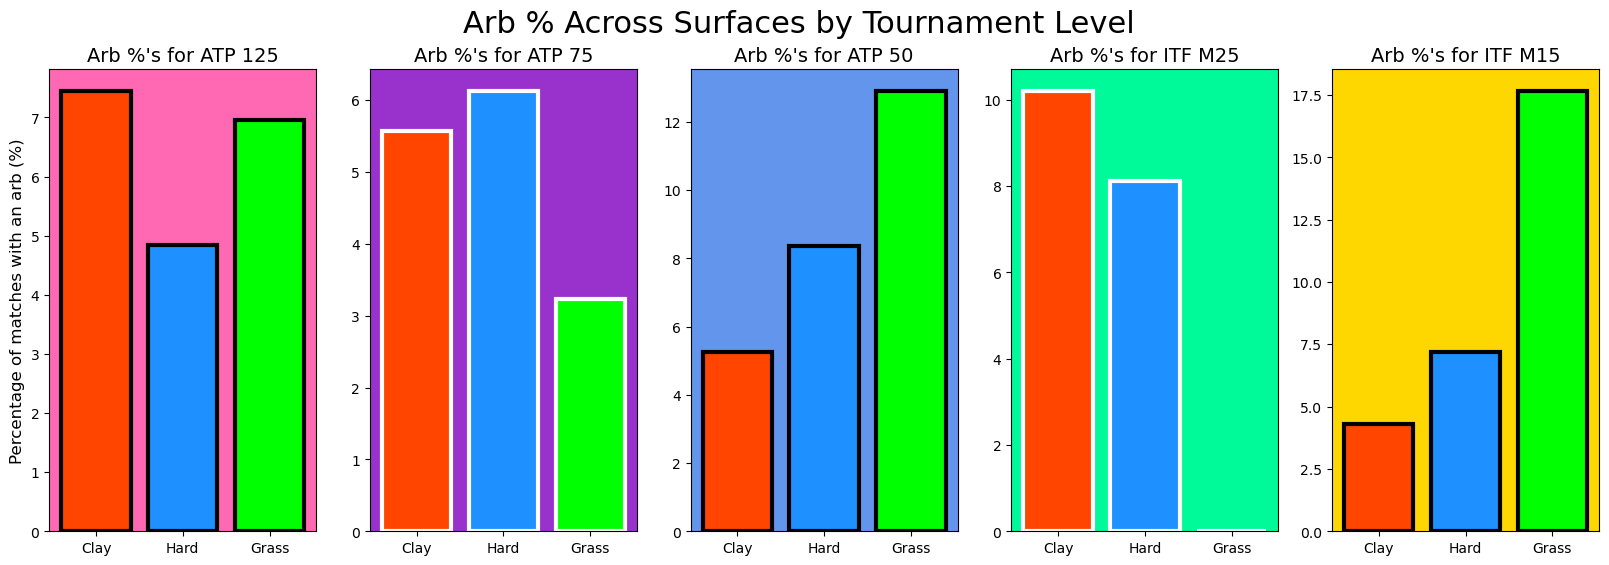

In [15]:
#comparing arb % among surfaces for each tournament level.

import matplotlib.pyplot as plt
import numpy as np

def arbitrage_percentage_surface_tournament_levels(odds_list):
    match_counter = [[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0]]
    arb_matches = [[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0]]
    arb_percentages = [[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0]]
    for l in range(5):
        for i in range(len(odds_list[l])):
            for j in range(len(odds_list[l][i][1])):
                if len(odds_list[l][i][1][j]) == 1:
                    continue
                net_return = arb_return(odds_list[l][i][1][j])
                if odds_list[l][i][0][1] == 'Clay':
                    match_counter[l][0] += 1
                    if net_return > 0 :
                        arb_matches[l][0] += 1
                elif odds_list[l][i][0][1] == 'Hard':
                    match_counter[l][1] += 1
                    if net_return > 0 :
                        arb_matches[l][1] += 1
                elif odds_list[l][i][0][1] == 'Grass':
                    match_counter[l][2] += 1
                    if net_return > 0 :
                        arb_matches[l][2] += 1
    for m in range(5):
        for n in range(3):
            if match_counter[m][n] == 0:
                arb_percentages[m][n] = 0
            else:
                arb_percentages[m][n] = 100*(arb_matches[m][n]/match_counter[m][n])
    return arb_percentages

surface_types = ['Clay','Hard','Grass']
tournament_colours = ['hotpink','darkorchid','cornflowerblue','mediumspringgreen','gold']
surface_colours = ['orangered','dodgerblue','lime']
fig, (ax1,ax2,ax3,ax4,ax5) = plt.subplots(1,5,figsize = (20,6),gridspec_kw={'width_ratios': [1,1,1,1,1]})
fig.suptitle('Arb % Across Surfaces by Tournament Level',fontsize = '22')
ax1.bar(surface_types,arbitrage_percentage_surface_tournament_levels(tennis_odds)[0],color = surface_colours,edgecolor = 'black',linewidth = 3)
ax1.set_fc(tournament_colours[0])
ax1.set_title("Arb %'s for ATP 125",fontsize = '14')
ax1.set_ylabel('Percentage of matches with an arb (%)',fontsize = '12')
ax2.bar(surface_types,arbitrage_percentage_surface_tournament_levels(tennis_odds)[1],color = surface_colours,edgecolor = 'white',linewidth = 3)
ax2.set_fc(tournament_colours[1])
ax2.set_title("Arb %'s for ATP 75",fontsize = '14')
ax3.bar(surface_types,arbitrage_percentage_surface_tournament_levels(tennis_odds)[2],color = surface_colours,edgecolor = 'black',linewidth = 3)
ax3.set_fc(tournament_colours[2])
ax3.set_title("Arb %'s for ATP 50",fontsize = '14')
ax4.bar(surface_types,arbitrage_percentage_surface_tournament_levels(tennis_odds)[3],color = surface_colours,edgecolor = 'white',linewidth = 3)
ax4.set_fc(tournament_colours[3])
ax4.set_title("Arb %'s for ITF M25",fontsize = '14')
ax5.bar(surface_types,arbitrage_percentage_surface_tournament_levels(tennis_odds)[4],color = surface_colours,edgecolor = 'black',linewidth = 3)
ax5.set_fc(tournament_colours[4])
ax5.set_title("Arb %'s for ITF M15",fontsize = '14')
plt.show()

Here, our data is a bit mixed. It feels like grass is better for arb % especially for ATP 50 and ITF M15, but we can't say that definitively. Also, an important note is that our grass data is quite noisy to begin with, and now comparing across each tournament level individually makes it even noisier. For ATP 75 and ATP 50 especially, we only have 1 grass tournament for each. Here, our data suggests that grass is a little better, but we should also look at the arb return per match to get a more complete comparison. 

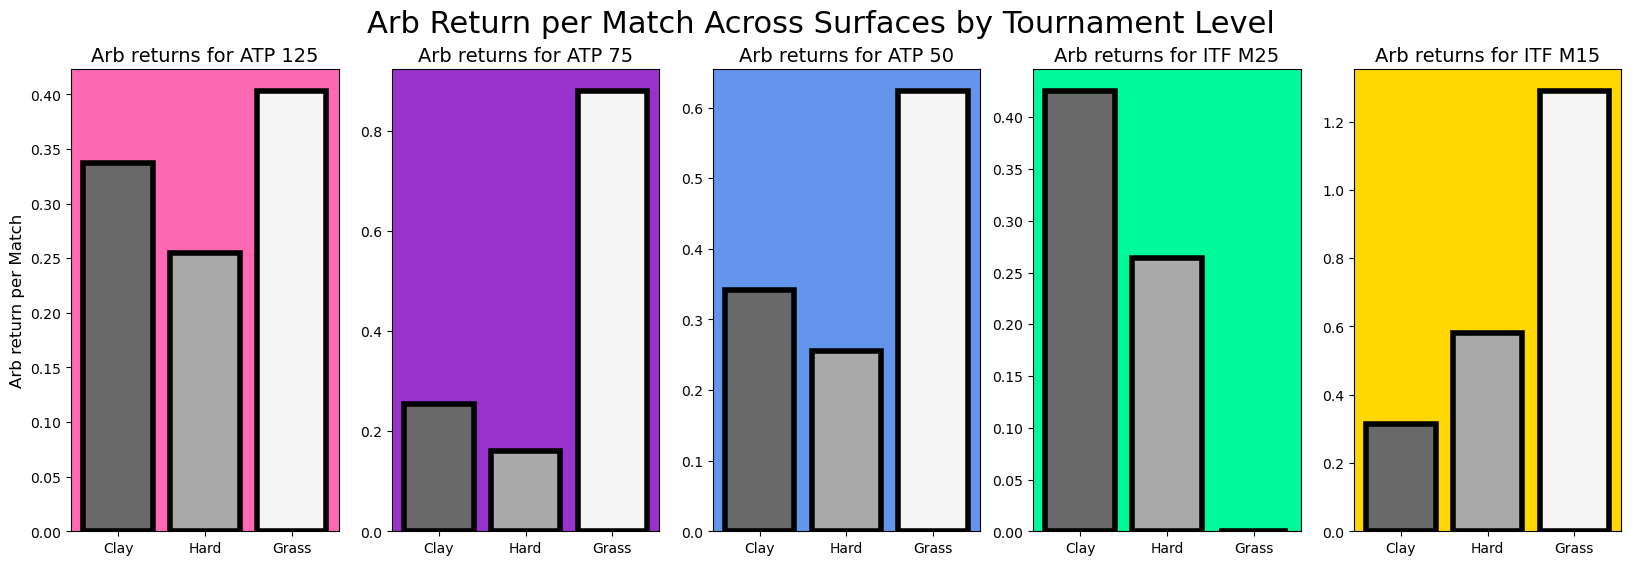

In [16]:
#comparing the average positive arb return per match among surface types for each tournament level 

import matplotlib.pyplot as plt
import numpy as np

def arbitrage_pos_return_surface_tournament_levels(odds_list):
    match_counter = [[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0]]
    total_positive_return = [[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0]]
    arb_return_per_match = [[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0]]
    for l in range(5):
        for i in range(len(odds_list[l])):
            for j in range(len(odds_list[l][i][1])):
                if len(odds_list[l][i][1][j]) == 1:
                    continue
                net_return = arb_return(odds_list[l][i][1][j])
                if odds_list[l][i][0][1] == 'Clay':
                    match_counter[l][0] += 1
                    if net_return > 0 :
                        total_positive_return[l][0] += arb_return(odds_list[l][i][1][j])
                elif odds_list[l][i][0][1] == 'Hard':
                    match_counter[l][1] += 1
                    if net_return > 0 :
                        total_positive_return[l][1] += arb_return(odds_list[l][i][1][j])
                elif odds_list[l][i][0][1] == 'Grass':
                    match_counter[l][2] += 1
                    if net_return > 0 :
                        total_positive_return[l][2] += arb_return(odds_list[l][i][1][j])
    for m in range(5):
        for n in range(3):
            if match_counter[m][n] == 0:
                arb_return_per_match[m][n] = 0
            else:
                arb_return_per_match[m][n] = total_positive_return[m][n]/match_counter[m][n]
    return arb_return_per_match

surface_types = ['Clay','Hard','Grass']
tournament_colours = ['hotpink','darkorchid','cornflowerblue','mediumspringgreen','gold']
greyscale_3_colours = ['dimgrey','darkgrey','whitesmoke']
fig, (ax1,ax2,ax3,ax4,ax5) = plt.subplots(1,5,figsize = (20,6),gridspec_kw={'width_ratios': [1,1,1,1,1]})
fig.suptitle('Arb Return per Match Across Surfaces by Tournament Level',fontsize = '22')
ax1.bar(surface_types,arbitrage_pos_return_surface_tournament_levels(tennis_odds)[0],color = greyscale_3_colours,edgecolor = 'black',linewidth = 4)
ax1.set_fc(tournament_colours[0])
ax1.set_title("Arb returns for ATP 125",fontsize = '14')
ax1.set_ylabel('Arb return per Match',fontsize = '12')
ax2.bar(surface_types,arbitrage_pos_return_surface_tournament_levels(tennis_odds)[1],color = greyscale_3_colours,edgecolor = 'black',linewidth = 4)
ax2.set_fc(tournament_colours[1])
ax2.set_title("Arb returns for ATP 75",fontsize = '14')
ax3.bar(surface_types,arbitrage_pos_return_surface_tournament_levels(tennis_odds)[2],color = greyscale_3_colours,edgecolor = 'black',linewidth = 4)
ax3.set_fc(tournament_colours[2])
ax3.set_title("Arb returns for ATP 50",fontsize = '14')
ax4.bar(surface_types,arbitrage_pos_return_surface_tournament_levels(tennis_odds)[3],color = greyscale_3_colours,edgecolor = 'black',linewidth = 4)
ax4.set_fc(tournament_colours[3])
ax4.set_title("Arb returns for ITF M25",fontsize = '14')
ax5.bar(surface_types,arbitrage_pos_return_surface_tournament_levels(tennis_odds)[4],color = greyscale_3_colours,edgecolor = 'black',linewidth = 4)
ax5.set_fc(tournament_colours[4])
ax5.set_title("Arb returns for ITF M15",fontsize = '14')
plt.show()

Here we get much more consistent data; grass has the greatest arb return per match in all 4 tournament levels it’s in. Also, clay has a higher arb return per match than hard for 4/5 of the tournament levels. This measure tells a bit more, and it’s interesting to see the effect surface level has. There are several reasons for this, and I will look more into how and why surface type and tournament level affect arbitrage opportunities later.

## Comparing Arbitrage Opportunities Across Tournament Rounds

I finally wanted to compare arbitrage opportunities across the rounds of a tournament. Each of our tournaments is played between 32 people and therefore has 5 rounds. Tournament level and surface type shouldn’t impact our data much. This is because each tournament has:

* 16 Round of 32 Matches
* 8 Round of 16 Matches
* 4 Quarterfinal Matches
* 2 Semi-Final Matches
* 1 Finals Match

This isn’t exact for every tournament, as there are some matches with no odds and some walkover matches, but it means the proportion of matches in each tournament level and surface type is very similar for every round. I would expect there to be more arbitrage opportunities in earlier rounds as there is more uncertainty surrounding the matches.

An important note is that the data for later rounds becomes much noisier. As we have 100 tournaments, we can see from above that we have roughly 1,600 matches in the round of 32, and only 100 finals matches. To compare arbitrage opportunities, I first compare arb % across tournament rounds below.

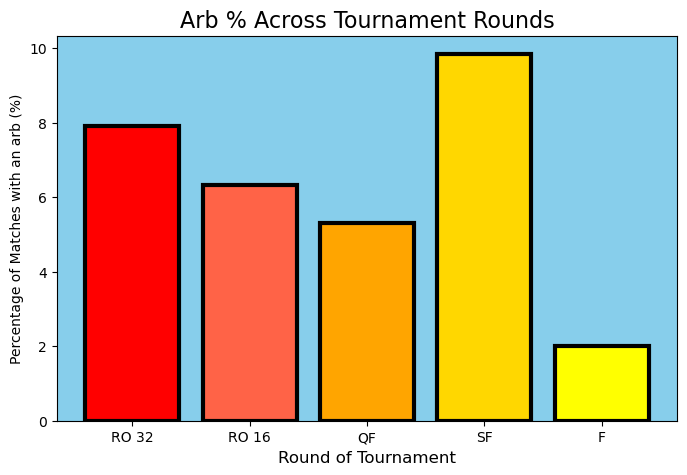

In [17]:
#comparing arb % across each round of the tournaments.

import matplotlib.pyplot as plt
import numpy as np

def round_converter_nums(num):
    if 0 <= num <= 15:
        return 0
    elif 16<= num <= 23:
        return 1
    elif  24<= num <= 27:
        return 2
    elif 28<= num <= 29:
        return 3
    elif num == 30:
        return 4
def arbitrage_percentage_rounds(odds_list):
    match_counter = [0] * 5
    arb_matches = [0] * 5
    arb_percentages = [0] * 5
    for l in range(5):
        for i in range(len(odds_list[l])):
            for j in range(len(odds_list[l][i][1])):
                if len(odds_list[l][i][1][j]) == 1:
                    continue
                match_counter[round_converter_nums(j)] += 1
                net_return = arb_return(odds_list[l][i][1][j])
                if net_return > 0:
                    arb_matches[round_converter_nums(j)] += 1
    for m in range(5):
        arb_percentages[m] = 100*(arb_matches[m]/match_counter[m])
    return arb_percentages

round_labels = ['RO 32','RO 16','QF','SF','F']
round_colours = ['red','tomato','orange','gold','yellow']        
plt.figure(figsize=(8,5))
plt.bar(round_labels,arbitrage_percentage_rounds(tennis_odds), color = round_colours, edgecolor = 'black', linewidth = 3)
ax = plt.gca()
ax.set_facecolor('skyblue')
plt.title('Arb % Across Tournament Rounds',fontsize = '16')
plt.xlabel('Round of Tournament',fontsize = '12')
plt.ylabel('Percentage of Matches with an arb (%)')
plt.show()

My prediction of decreasing arbitrage opportunities for later rounds of the tournament is accurate, except for the semifinals, which is an outlier. This is likely in part due to noisier data, but there are some possible reasons for it too. Before I look at better understanding the findings here, I want to compare the average positive arb return per match across the different rounds of the tournament.

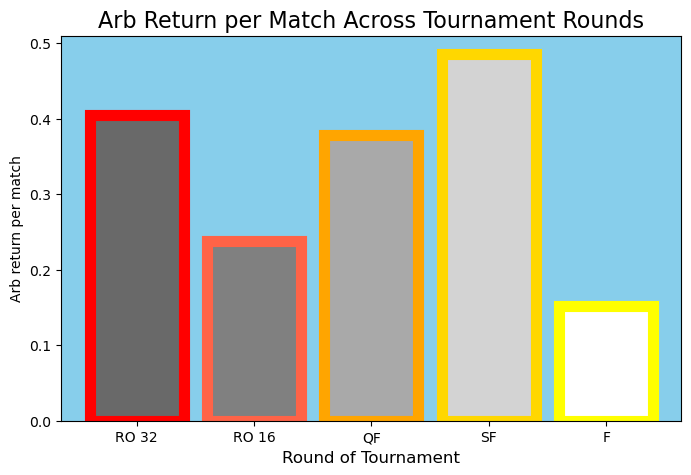

In [18]:
#comparing the average positive arb return per match among rounds of the tournaments

import matplotlib.pyplot as plt
import numpy as np

def arbitrage_pos_return_rounds(odds_list):
    match_counter = [0] * 5
    total_positive_return = [0] * 5
    arb_return_per_match = [0] * 5
    for l in range(5):
        for i in range(len(odds_list[l])):
            for j in range(len(odds_list[l][i][1])):
                if len(odds_list[l][i][1][j]) == 1:
                    continue
                match_counter[round_converter_nums(j)] += 1
                net_return = arb_return(odds_list[l][i][1][j])
                if net_return > 0:
                    total_positive_return[round_converter_nums(j)] += net_return
    for m in range(5):
        arb_return_per_match[m] = total_positive_return[m]/match_counter[m]
    return arb_return_per_match

round_labels = ['RO 32','RO 16','QF','SF','F']
round_colours = ['red','tomato','orange','gold','yellow']  
greyscale_5_colours = ['dimgrey','grey','darkgrey','lightgrey','white']
plt.figure(figsize=(8,5))
plt.bar(round_labels,arbitrage_pos_return_rounds(tennis_odds), color = greyscale_5_colours, edgecolor = round_colours, linewidth = 8)
ax = plt.gca()
ax.set_facecolor('skyblue')
plt.xlabel('Round of Tournament',fontsize = '12')
plt.ylabel('Arb return per match')
plt.title('Arb Return per Match Across Tournament Rounds',fontsize = '16')
plt.show()

Here, our data is quite mixed, and we will think about why that is later. This data is per match, and because later rounds have many fewer matches, we still have many more arbitrage opportunities in the round of 32 compared to the semifinals.

## How Tournament Level impacts arbitrage opportunities

We first looked at how arbitrage opportunities change with tournament level and found that, in general, lower tournament levels have better arbitrage opportunities. I wanted to think about why this could be the case and have listed some possible reasons below:

* Less betting volume. Smaller tournaments have fewer bets placed on them, and therefore bookmakers have less incentive to keep prices as competitive as possible. This can lead to more bookmaker disagreement and better arbitrage opportunities.
* Less bookmaker attention. In a similar sense, because an ATP Challenger 125 match is a much bigger market for bookmakers than an ITF M15, they are less likely to devote as much attention to it, this can lead to more price discrepencies which leads to more arbitrage opportunities.
* Less information about players. For smaller tournaments, there is often less information about the players which can lead to greater disagreement between bookmaker’s odds which will increase the chance of an arb.

Overall, these reasons are mainly because lower-level tournaments get less focus. There are some drawbacks to this, though; higher-level tournaments often have:

* More bookmakers
* Less betting limits

This means that arbs can be easier to capitalise upon in higher tournament levels. It’s easy to just say that the ITF tournaments are better as they have more arbitrage opportunities but it isn’t that simple. Having an arbitrage opportunity in a match with only 2 bookmakers in which both have low limits means that the profit you can make is significantly smaller than it would be with higher betting limits.

Overall, it’s tough to say exactly what is better; there are positives and negatives to both focusing on higher and lower tournament levels. In reality, you don’t need to focus exclusively on either, but these are important factors to consider when looking into potential future arbitrage opportunities.

## How Surface Type impacts arbitrage opportunities

We then looked at how arbitrage opportunities are affected by surface type. The conclusion was that grass was the best for finding arbitrage opportunities; clay was a little better than hard too. As grass was so strong, I wanted to focus on the reasoning for this. There isn’t as obvious an answer as we found for tournament level, but there are a few potential reasons:

* Grass has a much shorter season. Grass is only played for a short season of the year and is much less common. This means bookmakers have much less recent grass tournament data to work from, and this can lead to larger price disagreement between bookmakers, which is good for arb opportunities.
* Grass impacts player performance. Some players are stronger or weaker on different surface types, and bookmakers can often disagree on how a player’s performance will translate to grass. This can increase bookmaker disagreement and arbitrage opportunities.
* Grass tournaments are common in the UK. The past odds I have looked at are, I believe, all from UK bookmakers; this means that for grass tournaments in the UK they probably have greater bookmaker coverage in general, which could lead to more arb opportunities.

The first two points both relate to grass tournaments being much less common. This means that there are fewer grass tournaments to bet on. This means that whilst grass seems to be a better surface type for arb opportunities, we won’t always be able to find grass tournaments to bet on.

Overall, it’s hard to know how much of the increase in arbitrage opportunities grass has over other surface types is because of the surface type itself or because of more UK tournaments. We could look at comparing grass tournaments in and outside of the UK, but this is complex as they vary across tournament levels and there isn’t much data to compare. Grass seems to be the best surface for arb opportunities, but it also comes with the drawback of fewer tournaments, as I mentioned above. This means that while grass seems have better arbitrage opportunities per match, there are fewer arbitrage opportunities overall.

## How Round of Tournament impacts arbitrage opportunities.

There was no clear correlation between rounds and arbitrage opportunities. It is also important to note that there are much less semi finals and finals matches, which means that the data is much noisier. There are some possible reasons why arbitrage opportunities could be higher in earlier and later rounds; I’ll list a few here. Reasons that arbitrage opportunities could be higher in earlier rounds:

* Less information. For earlier rounds, there is less information, which can often make the matches harder to predict and arbs more common.
* Less attention. Similar to how some lower-level tournaments receive less information, so do earlier rounds. This can lead to better arbitrage opportunities.

There are some possible reasons why later rounds could have better arbitrage opportunities too; these consist of:

* Player conditions. Some players might have played more matches in quicker succession and therefore might be more fatigued. Due to walkovers and retirements, some players could have played much more going into a later round match, which can increase bookmaker disagreement.
* Recent performance can be interpreted differently. In later rounds, each player has won a few matches; these results can be interpreted differently by different bookmakers, which can lead to better arbitrage opportunities.

The main reasons why later rounds could have better arbitrage opportunities seems to come down to there being more information. In general, you would think this would decrease arbitrage opportunities, but the new information can be interpreted very differently among different bookmakers.

Overall, there is no clear relationship between tournament round and arbitrage opportunities, and we would need more data to better understand this relationship.

### Backtesting idea.

Backtesting is, in general, using past data to see how a strategy or model would have performed if you had applied it in the past. It’s a useful tool to judge strategies without risking capital, and the general idea behind it is that what worked in the past might work in the future.

I could look specifically at one tournament level or one surface type, but I wanted to see overall, using all my data, how much return I could get. So I have looked at the total profit I would make if I had been able to bet on any of the matches with a £100 stake and bet specifically when there is an arbitrage opportunity.

In [19]:
#calculating total profit from backtesting idea

def arbitrage_backtesting(odds_list):
    match_counter = 0
    arb_matches = 0 
    total_profit = 0
    for l in range(5):
        for i in range(len(odds_list[l])):
            for j in range(len(odds_list[l][i][1])):
                if len(odds_list[l][i][1][j]) == 1:
                    match_counter += 1
                    continue
                match_counter += 1
                net_return = arb_return(odds_list[l][i][1][j])
                if net_return > 0:
                    arb_matches += 1
                    total_profit += net_return
    print(f'In total we have looked at {match_counter} matches. If we had applied our strategy we would have made £{round(total_profit,2)} profit.')
    print(f'This profit was split among {arb_matches} arb matches, which means we would have made £{round(total_profit/arb_matches,2)} per arb match')
    print(f'This is also £{round(total_profit/match_counter,2)} per total match.')
    
arbitrage_backtesting(tennis_odds)

In total we have looked at 3100 matches. If we had applied our strategy we would have made £1080.89 profit.
This profit was split among 216 arb matches, which means we would have made £5.0 per arb match
This is also £0.35 per total match.


Our results from backtesting are fairly promising; overall, we made a sizeable profit, but it looks a lot less worthwhile when looking at the profit per match. It’s very important when backtesting to only use information that was available at the time to avoid look-ahead bias.

The odds I have collected are the closing odds for the matches, which means that they are the odds of each bookmaker as the match started. This means that we would have had this information at the time, but we also don’t know how long the arbitrages we capitalised on existed. We also likely have missed other arbitrage opportunities created from bookmakers changing odds, which happened long before the match started.

Another important thing to note is that the above profit is based on every match paying out, which might not be the case for some matches where one player retired. If a player retires, different bookmakers have different rules for whether to pay out. This might mean we get paid out and make a profit, but it could also mean that one bookmaker pays out and the other cancels the bet, and we could then lose money. Taking this into account, I would estimate our profit is closer to £750.

I also assumed (falsely) that we could bet £100 on every match and bet in exact penny increments, which would also reduce the total profit value slightly. We still likely would have made a nice profit from this strategy, but it’s impossible to say whether it’s worth the time invested, as we can’t know how long this would take. There are other considerations too, like the tournaments being held across the globe in many different time zones. Overall, our backtest shows some promise, but there are many obstacles that come alongside it.

# Summarising Our Findings

Overall, we have seen signs of promise when looking at sports betting arbitrage opportunities. There are many factors to consider and definite complexities of placing sure bets, but there is potential winnings to be made here. We have seen that, in general, lower tournament levels have more arbitrage opportunities per match but often have stricter regulations on bets, which makes the opportunities themselves harder to capitalise on. We have also seen that grass seems to be the best surface type, but this comes with the drawback of a shorter season, and we couldn’t yet find a clear correlation with tournament round. Sure bets aren’t a no-strings-attached way of making easy money, but they can be a way of making small risk-free returns under certain conditions. I wanted to summarise by looking at the positives and negatives of sure bets.

### Positives:

* For an arbitrage where all bets pay out, there is no risk and a guaranteed profit.
* There are a very large number of sports matches happening year-round across numerous sports and levels.
* Sporting odds change a lot, which often creates short periods where an arb is possible.
* Bookmakers sometimes have promotional offers with good odds, which can create arbitrage opportunities.
* Sports betting winnings are tax-free.

The 3rd point is useful and something we didn’t look at as we focused on closing odds. Often bookmakers change their odds at different times, which means there are sometimes short periods where arbs are possible when one bookmaker has increased odds for one side, and another hasn’t changed theirs, for example. This wasn’t captured in our data but is a useful thing to note.

Bookmakers having promotional offers is another positive too; this means that on occasion you can make a larger risk-free return, but they often have betting limits. In the UK, sports betting winnings are tax-free, which makes sports betting a more profitable idea.

But there are also many negatives and complications with capitalising on arbitrage opportunities.

### Negatives:

* The arb could disappear or diminish before you place all bets. Sports betting odds are constantly changing, and your opportunity could go before you place all the bets.
* There are many limits in sports betting, which reduce the amount you can profit.
* The money you can make is relatively little compared to the risk.
* Different bookmakers have different rules. This can lead to some scenarios where some bets are voided, and others aren’t, leaving you in a bad position.
* Bookmakers can void bets when they make an error in odds.
* Bookmakers unsurprisingly don’t like arbs and can place restrictions or ban accounts they suspect of making sure bets.

These are some important points, especially the last one. Bookmakers don’t like arbs as it’s a way they can lose money; it’s similar to how casinos won’t like people counting cards. Both are legal, but in both cases they will try to stop you as best as possible. This makes it harder to make use of arbitrage opportunities, as trying to hide doing it by betting with larger increments decreases your return. It’s also important to read the terms for each bookmaker, as they are all a little different. For example, in tennis, when a player retires, different bookmakers have different conditions under which they pay:

* Some pay out regardless.
* Some pay out if the 1st set has been played.
* Some don’t pay out if one player retires.

There are other options too. As well as different bookmakers having different rules, the same bookmakers have different rules depending on the level of competition. In theory, you could negate the risk of one bet getting voided and the other not if you only made sure bets on betting companies with matching rules, but this massively reduces your chance of finding an arbitrage.

### What we could improve on

There are a few things I could improve to make the findings more accurate and useful. I think I did well getting a solid dataset of matches, but more matches would make the data even better. It would make the data less noisy and the findings more substantial. Our data was especially noisy when comparing one variable while controlling for another, for example, comparing arbitrage opportunities among tournament levels for each surface type. I could have also looked at other sports; I did this a little but didn't include it, as I wanted to just focus on tennis tournaments, as I found this to be the most promising and interesting.    

The main reason I didn’t analyse more matches is that I had to manually input the odds values for every match. Having an automated way of collecting odds by using an API or web scraping to find odds would be a better way of doing it and would mean you could analyse 10,000s or 100,000s of matches and scale up very nicely. This would make the data much more accurate and could also be used in finding current arbitrage opportunities to capitalise on.

Another improvement I could make is finding a website with more bookmakers. The one I looked at seemed to just have bookmakers from the UK, and it’s possible other regions could have more bookmakers and/or more arbitrage opportunities. I think in general you can only bet on bookmakers within your region, so I focused on UK odds, but it’s possible other regions are better for arbitrage opportunities, and this is something I could look more into.

A final improvement I could make is that I could have looked more specifically at the rules and regulations, including the different rules for when one player retires. This is very important, as different bookmakers have different rules, and one bookmaker voiding your bet and another not is one of the main ways the sure bets I looked at can go wrong. The main reason I didn’t do this was that there are many bookmakers, all of which have different rules for which they payout and the rules are sometimes tournament-level dependent too. To account for the risks of one bookmaker cancelling odds and another not, you could decide to only bet on matches with a sufficiently high return.

Looking at the rules and regulations would be very time-consuming and tedious but could let us have a stronger conclusion as to the best tournament level to focus on. We found that lower-level tournaments have more arbitrage opportunities per match, but it is not clear if this makes them better for sure bets, as they come with the downside of stricter betting limits. Knowing more of the specifics of betting limits and bookmaker coverage would help us to conclude the better tournament level for arbitrage opportunities.

### Final Summary:

There is some promise in finding sports betting arbitrage opportunities. I would probably avoid trying to make money here for someone planning to find arbitrage opportunities and place bets manually. There are some websites that give you current arbs which can help, but the betting rules and limits complicate things a lot.

It is definitely much more appealing if you could have a computer analyse current odds for many bookmakers simultaneously, as here you could often get more and better arb opportunities with constantly changing odds.

Overall, we compared how tournament level, surface type and round affect arbitrage opportunities by analysing arb % and arbitrage return per match across more than 3,000 matches. We also examined how betting limits and bookmaker-specific rules can make it more difficult to capitalise on these opportunities. While the analysis suggests that arbitrage opportunities can potentially be profitable, sure bets are by no means an easy way to make risk-free money in practice.